In [9]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Daten aus der SPSS-Kreuztabelle

sterne = np.array([1, 2, 3, 4, 5])

erfahrung_anzahl = np.array([20, 9, 22, 36, 413])
suche_anzahl = np.array([35, 3, 21, 44, 397])

n_erfahrung = erfahrung_anzahl.sum()
n_suche = suche_anzahl.sum()

# Umrechnung in Prozent innerhalb der Produktkategorie
erfahrung_prozent = erfahrung_anzahl / n_erfahrung * 100
suche_prozent = suche_anzahl / n_suche * 100

print("Erfahrungsgüter:", erfahrung_prozent)
print("Suchgüter:", suche_prozent)

Erfahrungsgüter: [ 4.   1.8  4.4  7.2 82.6]
Suchgüter: [ 7.   0.6  4.2  8.8 79.4]


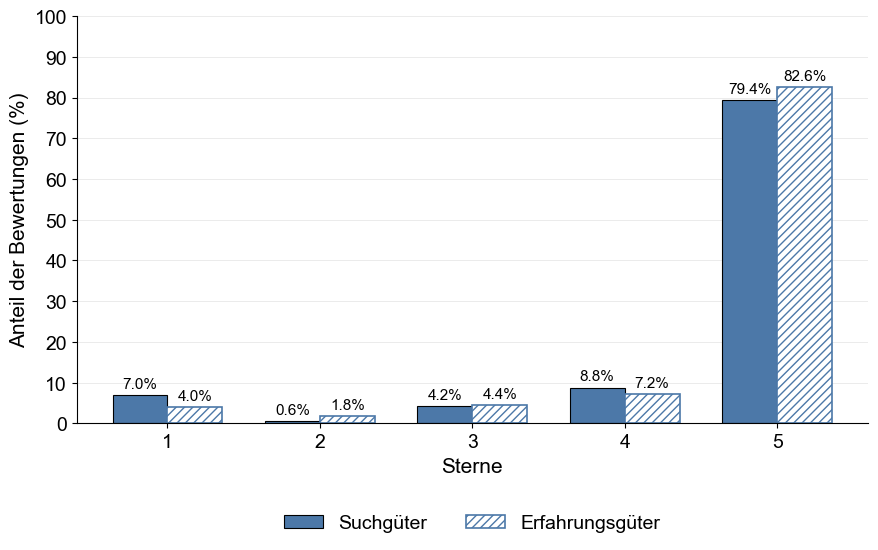

Gespeichert unter:
C:\Users\diana\OneDrive\Desktop\Analysen\Abbildungen\Abbildung_1_Sterneverteilung.png


In [10]:
## Verteilung der Sternebewertungen nach Produktkategorie

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path


# Daten aus dem SPSS-Output

sterne = np.array([1, 2, 3, 4, 5])

erfahrung_anzahl = np.array([20, 9, 22, 36, 413])
suche_anzahl = np.array([35, 3, 21, 44, 397])

erfahrung_prozent = erfahrung_anzahl / erfahrung_anzahl.sum() * 100
suche_prozent = suche_anzahl / suche_anzahl.sum() * 100


# Schrift und Layout

plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 14,
    "axes.labelsize": 15,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14
})

fig, ax = plt.subplots(figsize=(9, 5.8))

breite = 0.36
positionen = np.arange(len(sterne))

blau = "#4C78A8"


# Balken

balken_suche = ax.bar(
    positionen - breite / 2,
    suche_prozent,
    width=breite,
    label="Suchgüter",
    color=blau,
    edgecolor="black",
    linewidth=0.8
)

balken_erfahrung = ax.bar(
    positionen + breite / 2,
    erfahrung_prozent,
    width=breite,
    label="Erfahrungsgüter",
    color="white",
    edgecolor=blau,
    linewidth=1.2,
    hatch="////"
)


# Achsen

ax.set_xlabel("Sterne")
ax.set_ylabel("Anteil der Bewertungen (%)")

ax.set_xticks(positionen)
ax.set_xticklabels(["1", "2", "3", "4", "5"])

ax.set_ylim(0, 100)
ax.set_yticks(np.arange(0, 101, 10))

# Dezente horizontale Gitternetzlinien
ax.yaxis.grid(True, linewidth=0.5, alpha=0.35)
ax.set_axisbelow(True)

# Rahmen vereinfachen
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)


# Prozentwerte über den Balken

def beschrifte_balken(balken):
    for balkenobjekt in balken:
        hoehe = balkenobjekt.get_height()

        ax.text(
            balkenobjekt.get_x() + balkenobjekt.get_width() / 2,
            hoehe + 1,
            f"{hoehe:.1f}%",
            ha="center",
            va="bottom",
            fontsize=11
        )

beschrifte_balken(balken_suche)
beschrifte_balken(balken_erfahrung)


# Legende

ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.18),
    ncol=2,
    frameon=False
)

plt.tight_layout()


# Speichern

ausgabeordner = Path(
    r"C:\Users\diana\OneDrive\Desktop\Analysen\Abbildungen"
)
ausgabeordner.mkdir(parents=True, exist_ok=True)

dateipfad = ausgabeordner / "Abbildung_1_Sterneverteilung.png"

plt.savefig(
    dateipfad,
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

print(f"Gespeichert unter:\n{dateipfad}")

In [11]:
import numpy as np
import pandas as pd
import pyreadstat
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.colors import Normalize


# SPSS-Datensatz einlesen

dateipfad = Path(
    r"C:\Users\diana\OneDrive\Desktop\Analysen\Analyse_mit_review_length.sav"
)

df, meta = pyreadstat.read_sav(dateipfad)

# Variablennamen kontrollieren
print("Variablen im Datensatz:")
print(df.columns.tolist())

Variablen im Datensatz:
['product_id', 'product_name', 'good_type', 'price_USD', 'stars', 'review_text', 'Nr', 'review_text_clean', 'V8_A1', 'V8_A2', 'V8_A3', 'V8_A4', 'V8_A5', 'BERT_discrete', 'BERT_continuous', 'bert_p1', 'bert_p2', 'bert_p3', 'bert_p4', 'bert_p5', 'review_length', 'good_type_num', 'diff_cont', 'diff_disc', 'filter_$', 'agreement', 'good_1', 'good_2', 'ZPR_1', 'ZRE_1']


In [12]:
# Relevante Variablen auswählen und bereinigen

daten = df[
    ["good_type", "stars", "BERT_discrete"]
].dropna().copy()

daten["stars"] = daten["stars"].astype(int)
daten["BERT_discrete"] = daten["BERT_discrete"].astype(int)

print("\nProduktkategorien:")
print(daten["good_type"].value_counts())

print("\nSterne:")
print(daten["stars"].value_counts().sort_index())

print("\nBERT diskret:")
print(daten["BERT_discrete"].value_counts().sort_index())


Produktkategorien:
good_type
search        500
experience    500
Name: count, dtype: int64

Sterne:
stars
1     55
2     12
3     43
4     80
5    810
Name: count, dtype: int64

BERT diskret:
BERT_discrete
1     59
2     42
3     67
4    216
5    616
Name: count, dtype: int64


In [13]:
# Funktion für vollständige 5 × 5-Kreuztabelle

kategorien = [1, 2, 3, 4, 5]

def erstelle_matrix(gruppe):
    matrix = pd.crosstab(
        gruppe["stars"],
        gruppe["BERT_discrete"]
    )

    # Sicherstellen, dass auch leere Kategorien angezeigt werden
    matrix = matrix.reindex(
        index=kategorien,
        columns=kategorien,
        fill_value=0
    )

    return matrix


suchgueter = daten[
    daten["good_type"].astype(str).str.lower() == "search"
]

erfahrungsgueter = daten[
    daten["good_type"].astype(str).str.lower() == "experience"
]

matrix_suche = erstelle_matrix(suchgueter)
matrix_erfahrung = erstelle_matrix(erfahrungsgueter)

print("\nKonfusionsmatrix Suchgüter:")
print(matrix_suche)

print("\nKonfusionsmatrix Erfahrungsgüter:")
print(matrix_erfahrung)


Konfusionsmatrix Suchgüter:
BERT_discrete   1  2   3   4    5
stars                            
1              25  7   2   0    1
2               1  0   2   0    0
3               1  8   7   4    1
4               2  3  11  18   10
5               5  5  17  89  281

Konfusionsmatrix Erfahrungsgüter:
BERT_discrete   1  2   3   4    5
stars                            
1              11  6   1   0    2
2               2  2   5   0    0
3               4  8   7   3    0
4               1  0  10  15   10
5               7  3   5  87  311


In [14]:
## Gemeinsame Darstellungseinstellungen

plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 14,
    "axes.labelsize": 15,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14
})

maximalwert = max(
    matrix_suche.to_numpy().max(),
    matrix_erfahrung.to_numpy().max()
)

normierung = Normalize(
    vmin=0,
    vmax=maximalwert
)

ausgabeordner = Path(
    r"C:\Users\diana\OneDrive\Desktop\Analysen\Abbildungen"
)

ausgabeordner.mkdir(
    parents=True,
    exist_ok=True
)

In [2]:
### Erstellung der Heatmaps

def zeichne_heatmap(matrix, gruppenname, dateiname):
    werte = matrix.to_numpy()

    # Zeilenprozente:
    # Verteilung des BERT-Werts innerhalb jeder Sterneklasse
    zeilensummen = werte.sum(axis=1, keepdims=True)

    prozente = np.divide(
        werte,
        zeilensummen,
        out=np.zeros_like(werte, dtype=float),
        where=zeilensummen != 0
    ) * 100

    fig, ax = plt.subplots(figsize=(7.4, 6.4))

    bild = ax.imshow(
        werte,
        cmap="Blues",
        norm=normierung,
        aspect="equal"
    )

    # Achsenbeschriftung
    ax.set_xlabel("BERT (diskr.)")
    ax.set_ylabel("Sterne")

    ax.set_xticks(np.arange(5))
    ax.set_yticks(np.arange(5))

    ax.set_xticklabels(["1", "2", "3", "4", "5"])
    ax.set_yticklabels(["1", "2", "3", "4", "5"])

    # Dünne weiße Zellgrenzen
    ax.set_xticks(
        np.arange(-0.5, 5, 1),
        minor=True
    )
    ax.set_yticks(
        np.arange(-0.5, 5, 1),
        minor=True
    )

    ax.grid(
        which="minor",
        color="white",
        linewidth=1.5
    )

    ax.tick_params(
        which="minor",
        bottom=False,
        left=False
    )

    # Zahlen und Prozentwerte in die Zellen schreiben
    for zeile in range(5):
        for spalte in range(5):
            anzahl = werte[zeile, spalte]
            anteil = prozente[zeile, spalte]

            # Bei dunklen Zellen weiße Schrift verwenden
            if anzahl > maximalwert * 0.45:
                schriftfarbe = "white"
            else:
                schriftfarbe = "black"

            ax.text(
                spalte,
                zeile,
                f"{anzahl}\n({anteil:.1f}%)",
                ha="center",
                va="center",
                fontsize=12,
                color=schriftfarbe
            )

    # Farbskala
    farbskala = fig.colorbar(
        bild,
        ax=ax,
        fraction=0.046,
        pad=0.04
    )

    farbskala.set_label(
        "Anzahl der Bewertungen",
        fontsize=13
    )

    farbskala.ax.tick_params(
        labelsize=12
    )

    # Kein Titel innerhalb der Abbildung
    # Gruppenname wird nur zur Dateiausgabe verwendet

    plt.tight_layout()

    speicherpfad = ausgabeordner / dateiname

    plt.savefig(
        speicherpfad,
        dpi=300,
        bbox_inches="tight",
        facecolor="white"
    )

    plt.show()

    print(
        f"{gruppenname} gespeichert unter:\n"
        f"{speicherpfad}\n"
    )

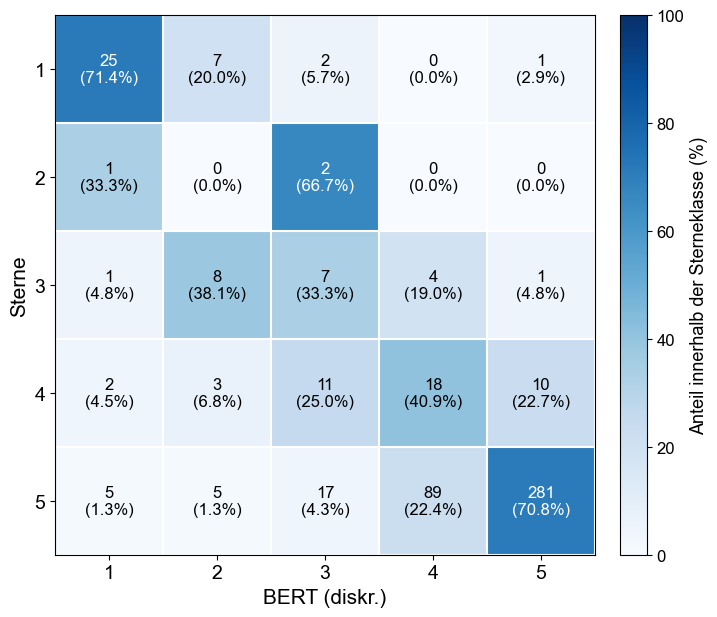

Suchgüter gespeichert unter:
C:\Users\diana\OneDrive\Desktop\Analysen\Abbildungen\Abbildung_2_Konfusionsmatrix_Suchgueter.png



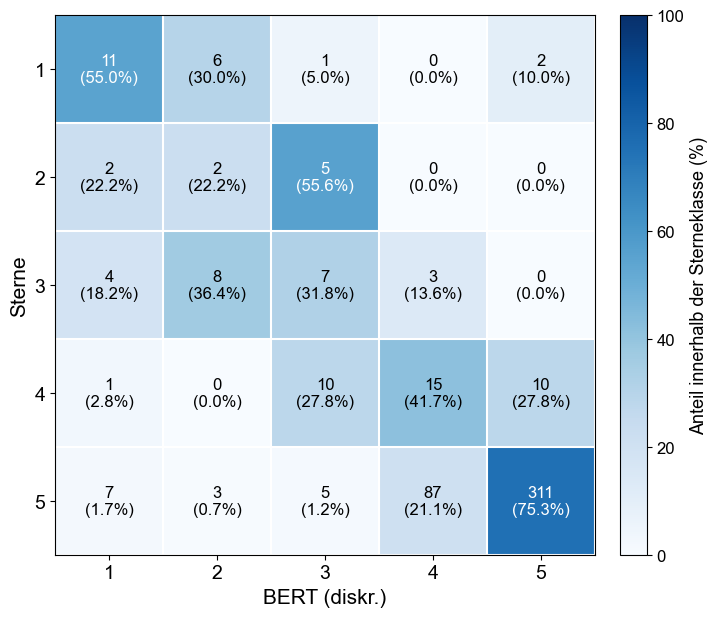

Erfahrungsgüter gespeichert unter:
C:\Users\diana\OneDrive\Desktop\Analysen\Abbildungen\Abbildung_3_Konfusionsmatrix_Erfahrungsgueter.png



In [24]:
zeichne_heatmap(
    matrix_suche,
    gruppenname="Suchgüter",
    dateiname="Abbildung_2_Konfusionsmatrix_Suchgueter.png"
)

zeichne_heatmap(
    matrix_erfahrung,
    gruppenname="Erfahrungsgüter",
    dateiname="Abbildung_3_Konfusionsmatrix_Erfahrungsgueter.png"
)

In [15]:
# Heatmap-Funktion

def zeichne_heatmap(matrix, gruppenname, dateiname):

    werte = matrix.to_numpy()

    # Zeilenprozente
    zeilensummen = werte.sum(axis=1, keepdims=True)

    prozente = np.divide(
        werte,
        zeilensummen,
        out=np.zeros_like(werte, dtype=float),
        where=zeilensummen != 0
    ) * 100

    plt.rcParams.update({
        "font.family": "Arial",
        "font.size": 13
    })

    fig, ax = plt.subplots(figsize=(7.2, 6.2))

    # Heatmap
    bild = ax.imshow(
        prozente,
        cmap="Blues",
        vmin=0,
        vmax=75,
        aspect="equal"
    )

    # Titel
    ax.set_title(
        gruppenname,
        fontsize=15,
        pad=12,
        weight="bold"
    )

    # Achsen
    ax.set_xlabel("BERT (diskr.)", fontsize=15)
    ax.set_ylabel("Sterne", fontsize=15)

    ax.set_xticks(np.arange(5))
    ax.set_yticks(np.arange(5))

    ax.set_xticklabels(["1", "2", "3", "4", "5"], fontsize=13)
    ax.set_yticklabels(["1", "2", "3", "4", "5"], fontsize=13)

    # Weiße Zellgrenzen
    ax.set_xticks(np.arange(-0.5, 5, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, 5, 1), minor=True)

    ax.grid(
        which="minor",
        color="white",
        linewidth=2
    )

    ax.tick_params(which="minor", bottom=False, left=False)

    # Prozentwerte in die Zellen
    for zeile in range(5):
        for spalte in range(5):

            anteil = prozente[zeile, spalte]

            schriftfarbe = "white" if anteil >= 45 else "black"

            ax.text(
                spalte,
                zeile,
                f"{anteil:.0f}%",
                ha="center",
                va="center",
                fontsize=11,
                color=schriftfarbe,
                weight="bold"
            )

    # Farbskala
    cbar = fig.colorbar(
        bild,
        ax=ax,
        fraction=0.046,
        pad=0.04
    )

    cbar.set_label(
        "Zeilenanteil (%)",
        fontsize=13
    )

    cbar.ax.tick_params(labelsize=12)

    plt.tight_layout()

    plt.savefig(
        ausgabeordner / dateiname,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()